In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [5]:
# 1. Configuration - Update this to your log path
LOG_PATH = "../logs/anomaly_model/version_1/metrics.csv"

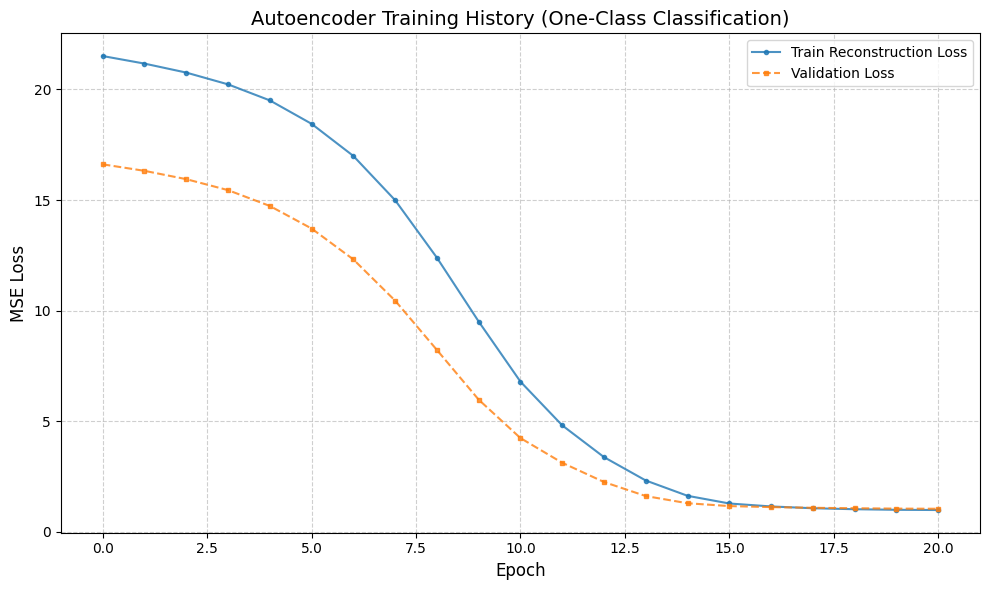

In [ ]:

def plot_training_history(csv_path):
    if not Path(csv_path).exists():
        print(f"Error: {csv_path} not found. Check your version number.")
        return

    # 2. Load and Clean Data
    df = pd.read_csv(csv_path)

    # df = df[df["epoch"] <= 20]

    # Collapse the 'gaps' by grouping by epoch and taking the mean
    # This combines the training row and validation row for each epoch
    metrics = df.groupby("epoch").mean(numeric_only=True).reset_index()

    # 3. Create the Plot
    plt.figure(figsize=(10, 6))
    
    if "train_reconst_loss" in metrics.columns:
        plt.plot(metrics["epoch"], metrics["train_reconst_loss"], 
                 label="Train Reconstruction Loss", marker='o', markersize=3, alpha=0.8)
    
    if "val_loss" in metrics.columns:
        plt.plot(metrics["epoch"], metrics["val_loss"], 
                 label="Validation Loss", linestyle='--', marker='s', markersize=3, alpha=0.8)

    # 4. Formatting
    plt.title("Autoencoder Training History (One-Class Classification)", fontsize=14)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("MSE Loss", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    
    # Optional: Log scale if the initial loss is very high compared to the end
    # plt.yscale('log') 

    plt.tight_layout()
    plt.show()

# Execute the plot
plot_training_history(LOG_PATH)